# Imports

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
#base
import pandas as pd
import numpy as np
from scipy import stats
# visual
import matplotlib.pyplot as plt
import seaborn as sns
#path
from pathlib import Path

In [4]:
# Path
BASE_DIR = Path.cwd().parent
DATA_DIR   = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SRC_DIR = BASE_DIR / "src"

PREPROCESSED_DIR = DATA_DIR / "preprocessed"

In [5]:
import sys
sys.path.append(str(SRC_DIR))

In [6]:
# visual
%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 12
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.spines.top"] = False 
plt.rcParams["axes.spines.right"] = False

sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.2)
sns.set_context("notebook")

COLORS = {
    'positive': '#2ecc71',
    'negative': '#e74c3c',
    'neutral': '#3498db',
    'highlight': '#f39c12',
    'secondary': '#9b59b6',
}

# Data Load

In [7]:
X_train = pd.read_csv(f'{PREPROCESSED_DIR}/X_train.csv')
X_val = pd.read_csv(f'{PREPROCESSED_DIR}/X_val.csv')
y_train = pd.read_csv(f'{PREPROCESSED_DIR}/y_train.csv')
y_val = pd.read_csv(f'{PREPROCESSED_DIR}/y_val.csv')

In [8]:
X_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,255,20,RL,70.0,8400.0,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
1,1067,60,RL,59.0,7837.0,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2009,WD,Normal
2,639,30,RL,67.0,8777.0,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,5,2008,WD,Normal
3,800,50,RL,60.0,7200.0,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,6,2007,WD,Normal
4,381,50,RL,50.0,5000.0,Pave,Pave,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal


In [9]:
X_val.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,893,20,RL,70.0,8414.0,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,2,2006,WD,Normal
1,1106,60,RL,98.0,12256.0,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal
2,414,30,RM,56.0,8960.0,Pave,Grvl,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,3,2010,WD,Normal
3,523,50,RM,50.0,5000.0,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,10,2006,WD,Normal
4,1037,20,RL,89.0,12898.0,Pave,NaN,IR1,HLS,AllPub,...,0,0,NaN,NaN,NaN,0,9,2009,WD,Normal


In [10]:
y_train.head()

,SalePrice
0,145000
1,178000
2,85000
3,175000
4,127000


In [11]:
y_val.head()

,SalePrice
0,154500
1,325000
2,115000
3,159000
4,315500


# Research

## Functions

In [40]:
def visualise_for_target(df):
    fig, ax = plt.subplots()
    ax.scatter(df, y_train)
    ax.set_title(df.name)
    plt.show()  

In [14]:
def quality_to_num(series: pd.Series) -> pd.Series:
    mapping = {
        "Ex": 5,
        "Gd": 4,
        "TA": 3,
        "Fa": 2,
        "Po": 1,
        "NA": 0,
    }
    return series.map(mapping).fillna(0)

In [13]:
quality_cols = [
        "ExterQual",
        "ExterCond",
        "BsmtQual",
        "BsmtCond",
        "HeatingQC",
        "KitchenQual",
        "FireplaceQu",
        "GarageQual",
        "GarageCond",
        "PoolQC",
    ]

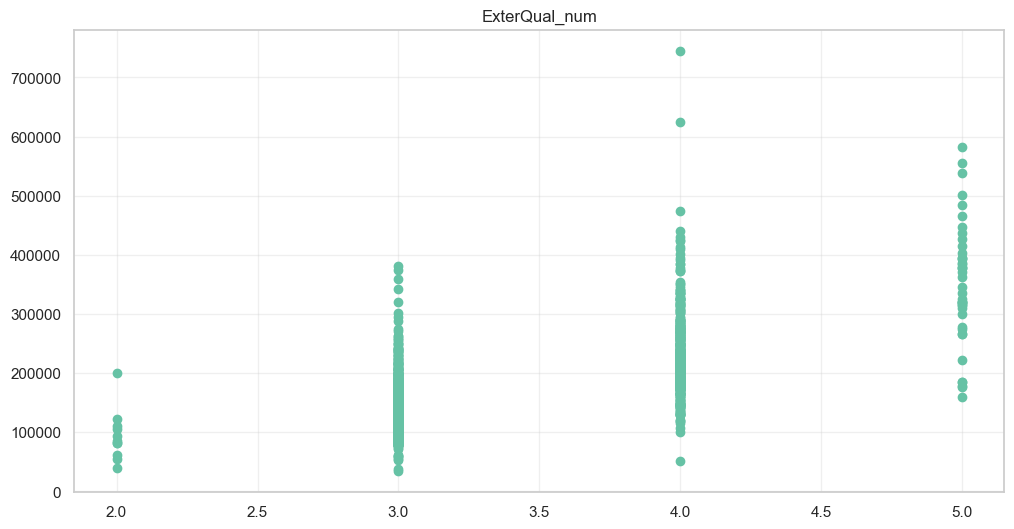

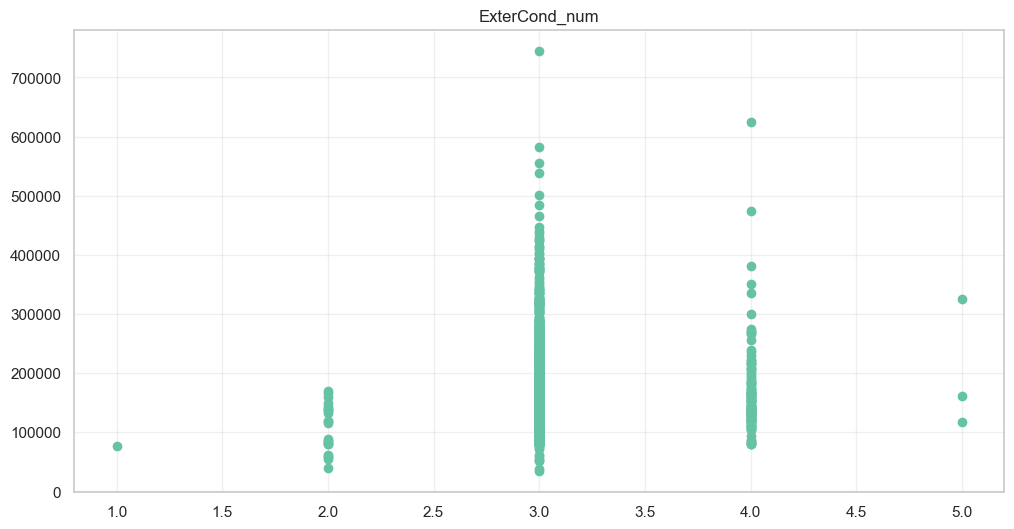

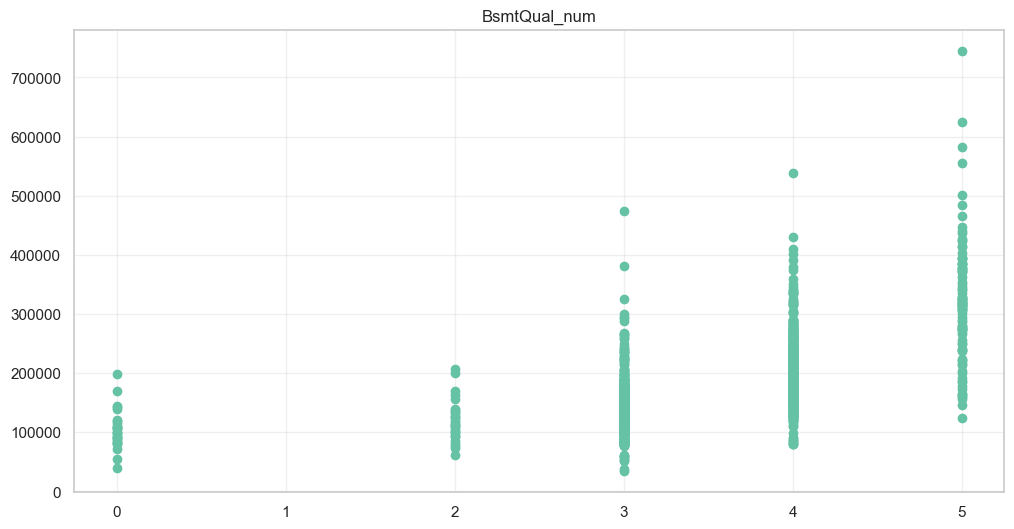

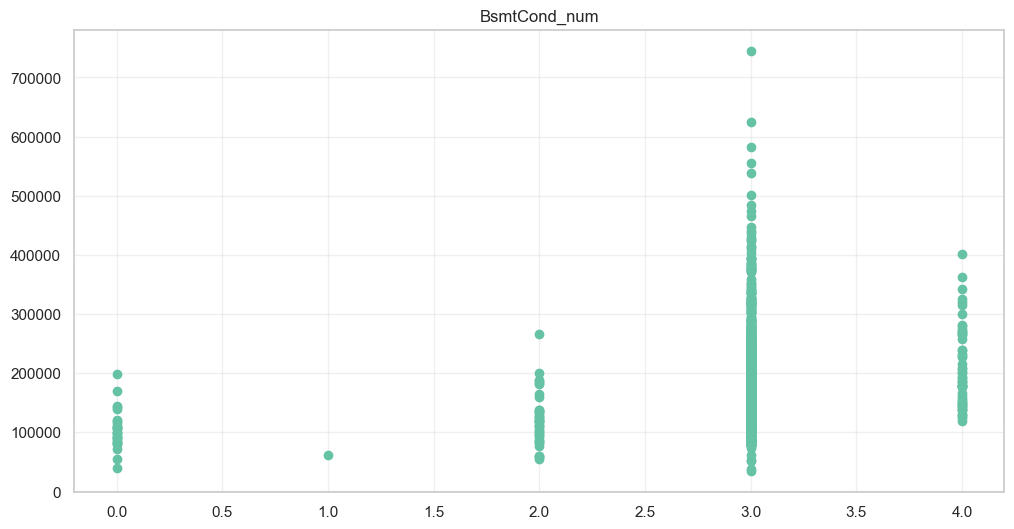

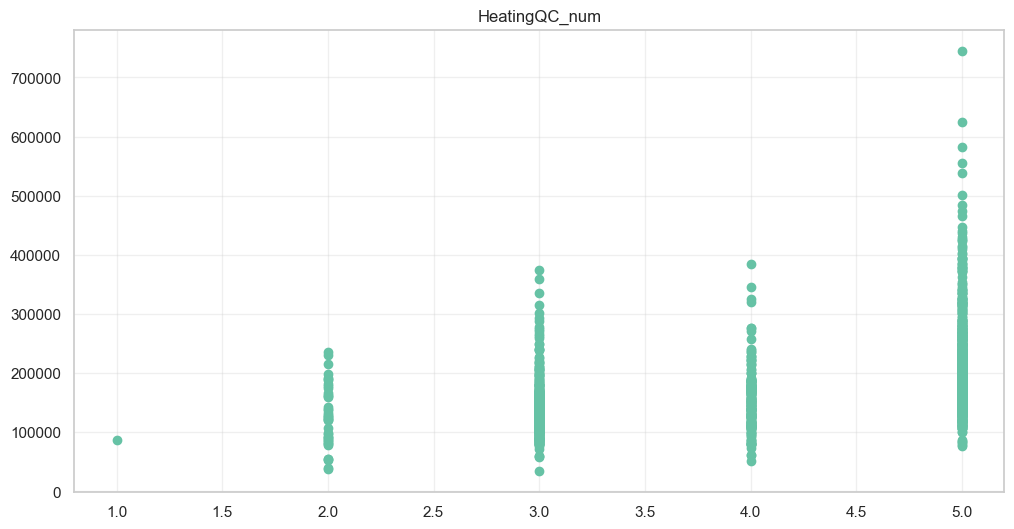

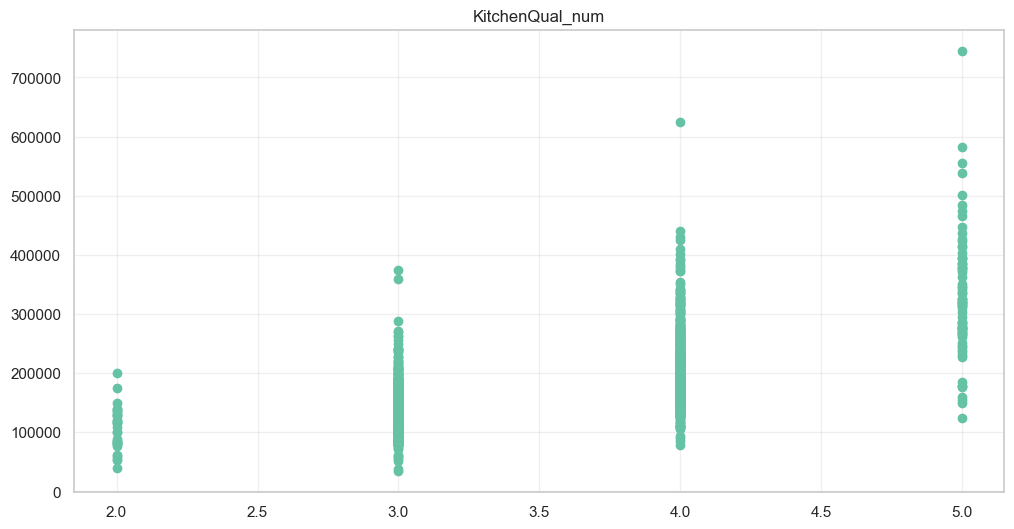

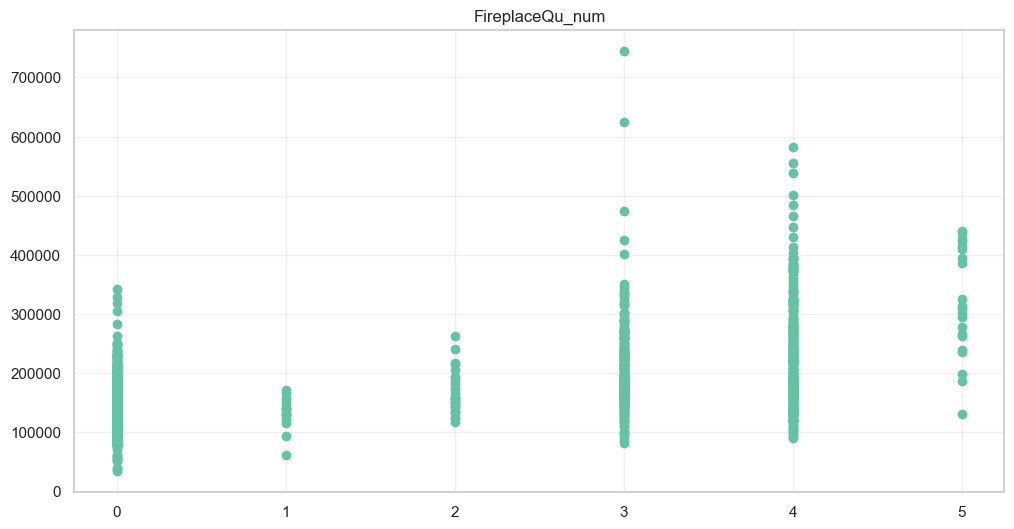

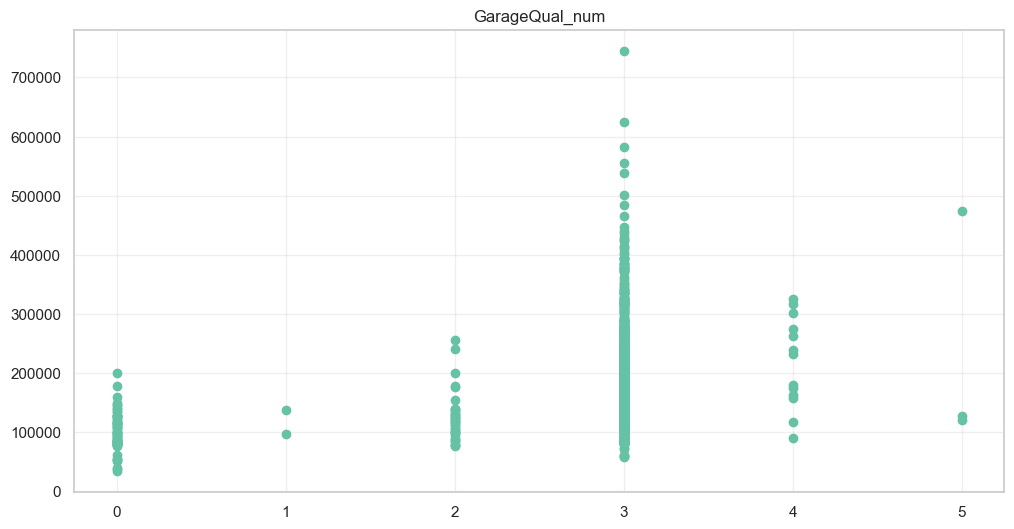

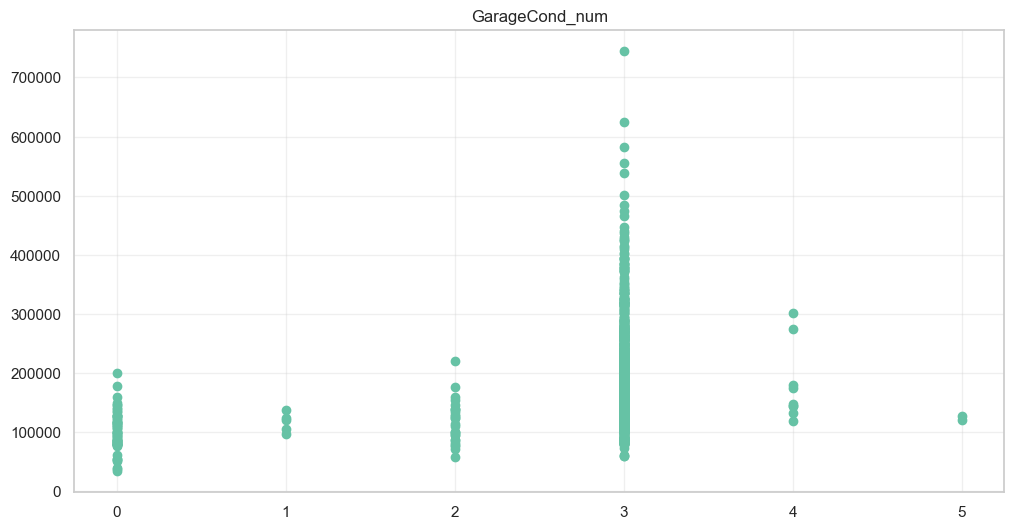

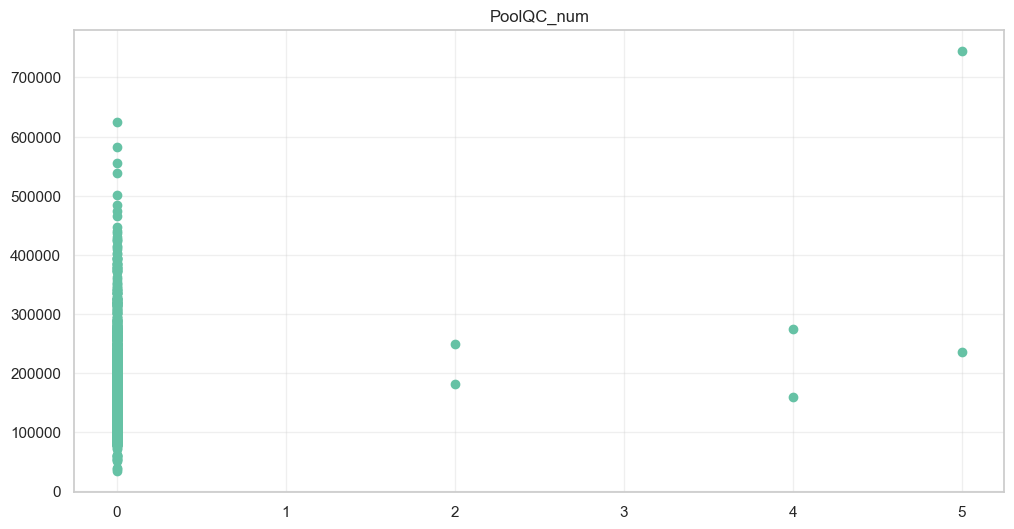

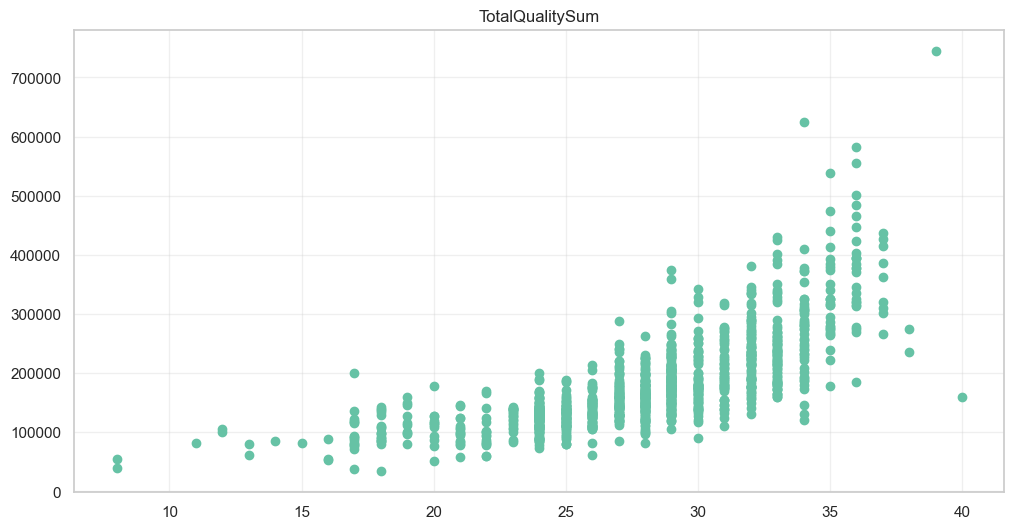

In [45]:
X_train["TotalQualitySum"] = 0
for col in quality_cols:
        X_train[f"{col}_num"] = quality_to_num(X_train[col])
        fig, ax = plt.subplots()
        ax.scatter(X_train[f"{col}_num"], y_train)
        ax.set_title(f"{col}_num")
        plt.show()
        X_train["TotalQualitySum"] += X_train[f"{col}_num"]
    
fig, ax = plt.subplots()
ax.scatter(X_train["TotalQualitySum"], y_train)
ax.set_title("TotalQualitySum")
plt.show()    

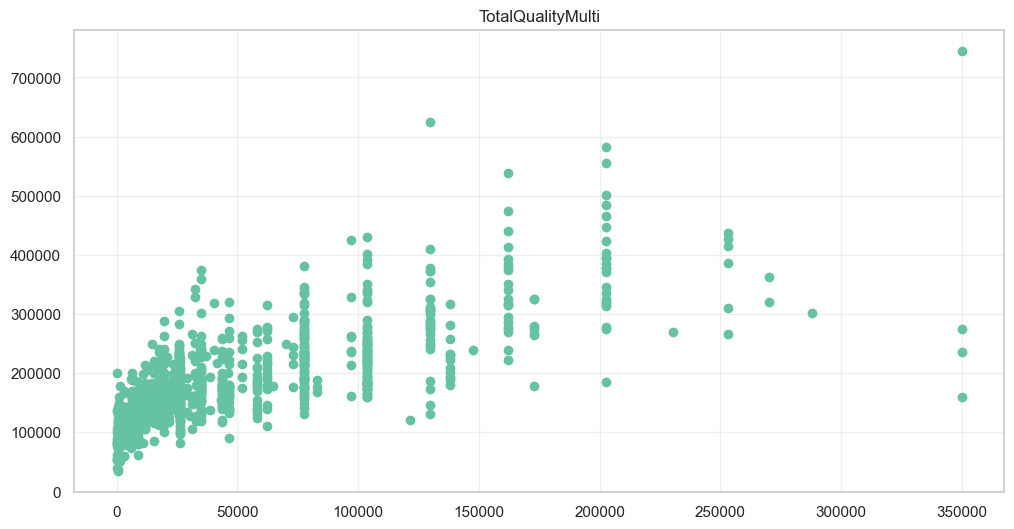

In [34]:
X_train["TotalQualityMulti"] = 1
for col in quality_cols:
        X_train["TotalQualityMulti"] *= X_train[f"{col}_num"].apply(lambda x: x if x != 0 else 1)
X_train["TotalQualityMulti"] = X_train["TotalQualityMulti"].clip(upper=350000)
fig, ax = plt.subplots()
ax.scatter(X_train["TotalQualityMulti"], y_train)
ax.set_title("TotalQualityMulti")
plt.show()  

In [36]:
X_train["OverallScore"] = X_train["OverallQual"] * X_train["OverallCond"]
    
X_train["HouseAge"] = X_train["YrSold"] - X_train["YearBuilt"]
X_train["RemodAge"] = X_train["YrSold"] - X_train["YearRemodAdd"]
    
X_train["TotalHouseSquare"] = X_train["TotalBsmtSF"] + X_train["GrLivArea"]

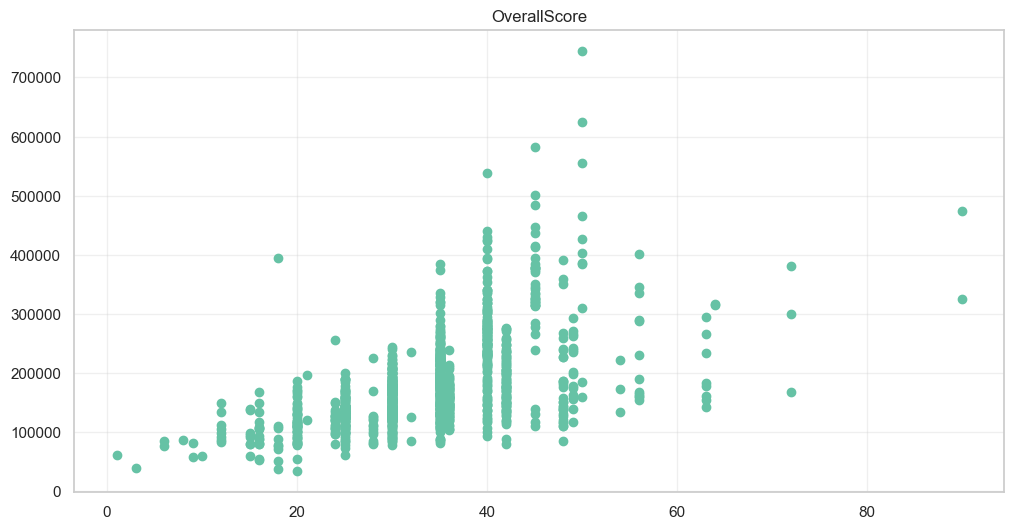

In [41]:
visualise_for_target(X_train["OverallScore"])

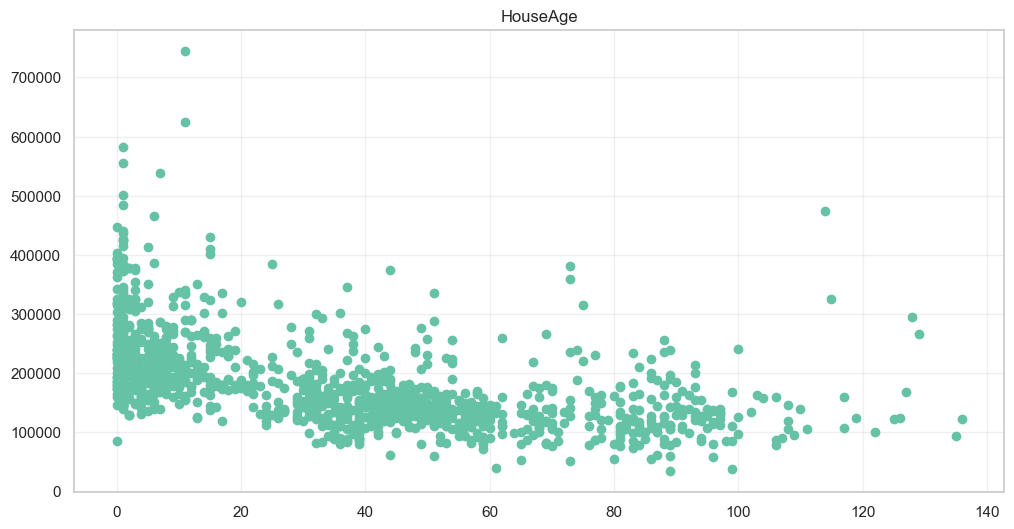

In [42]:
visualise_for_target(X_train["HouseAge"])

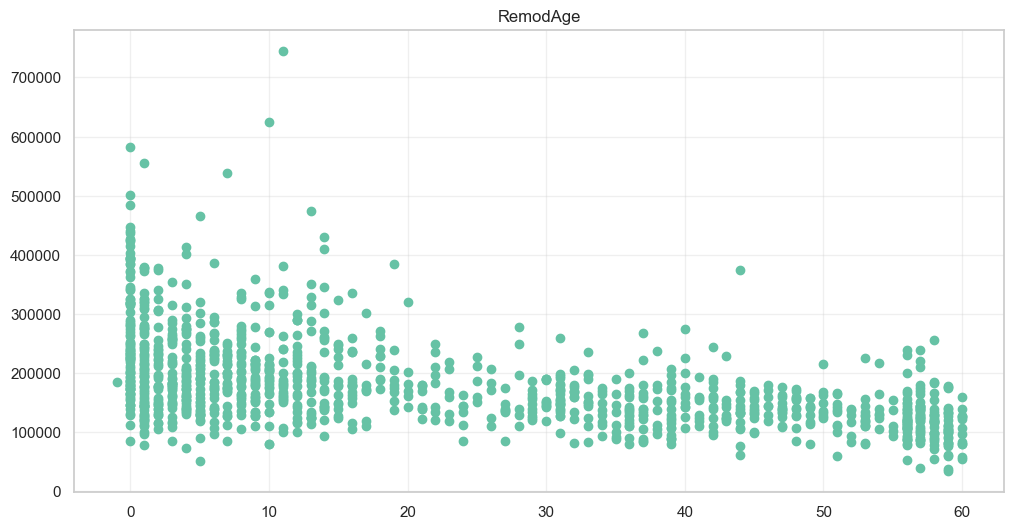

In [43]:
visualise_for_target(X_train["RemodAge"])

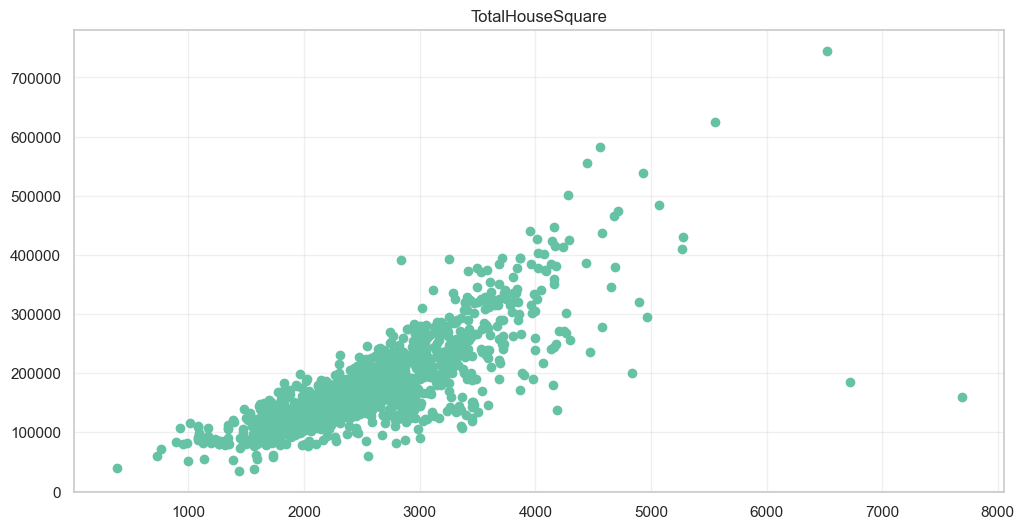

In [44]:
visualise_for_target(X_train["TotalHouseSquare"])

In [47]:
X_train['Quality*Square'] = X_train["TotalHouseSquare"] * X_train["TotalQualitySum"]

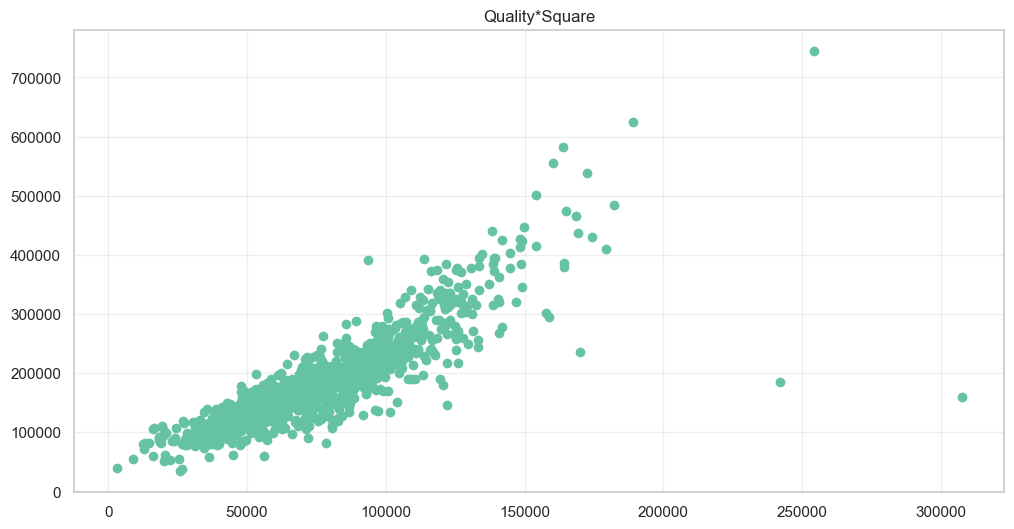

In [48]:
visualise_for_target(X_train["Quality*Square"])

In [50]:
X_train['QualityMulty*Square'] = X_train["TotalHouseSquare"] * X_train["TotalQualityMulti"]

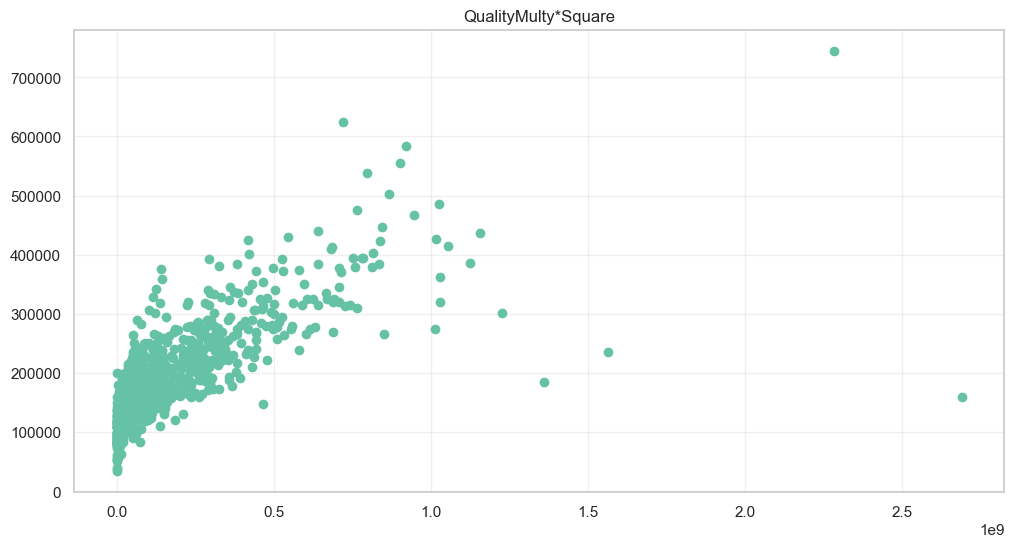

In [51]:
visualise_for_target(X_train['QualityMulty*Square'])